# Análisis Exploratorio de Datos (EDA)

**Caso de Estudio:** Analítica de Clientes — Predicción de Abandono  
**Asignatura:** SCY1101 — Programación para la Ciencia de Datos  
**Evaluación Parcial N°2**

---

## Contexto de Negocio

Una empresa de servicios digitales por suscripción enfrenta un aumento en su tasa de abandono (*churn*). Retener un cliente existente es entre **5 y 7 veces más barato** que adquirir uno nuevo (Reichheld & Sasser, 1990), lo que hace que la predicción temprana del abandono sea de alto valor estratégico.

El objetivo de este análisis exploratorio es:
1. Comprender la estructura, calidad y distribución del dataset.
2. Identificar patrones estadísticos asociados al abandono.
3. Formular hipótesis que guíen las decisiones de modelado en notebooks posteriores.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. Bibliotecas necesarias:

- `pandas >= 1.1.0` — Manipulación y análisis de datos tabulares.
- `numpy >= 2.0.0` — Operaciones numéricas vectorizadas.
- `matplotlib >= 3.7.1` — Visualizaciones estáticas.
- `seaborn >= 0.12.0` — Visualizaciones estadísticas de alto nivel.
- `scikit-learn >= 1.3` — Codificación de variables categóricas (`OneHotEncoder`).

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [34]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.style.use('bmh')

from sklearn.preprocessing import OneHotEncoder

In [35]:
data = pd.read_csv('../data/dataset_clientes.csv')
data.head()

,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
0,1,2021-10-27,66,Otro,Norte,Divorciado,9.243057e+05,524088.303055,2.448145e+06,455.406680,...,356,Bajo,Estandar,3,1,Tienda,Lunes,22,3824,1
1,2,2018-08-25,51,Masculino,Centro,Soltero,1.384687e+06,314259.751474,1.620569e+06,575.048508,...,307,Medio,Premium,4,1,App,Martes,10,4148,0
2,3,2019-05-25,48,Femenino,Norte,Casado,NaN,387192.316142,5.395040e+06,770.716904,...,232,Alto,Premium,4,1,App,Jueves,6,7200,0
3,4,2022-04-20,54,Masculino,Sur,Casado,4.369032e+05,417328.601856,2.999350e+06,442.722671,...,165,Alto,Estandar,2,1,App,Domingo,16,1782,1
4,5,2020-03-19,31,Otro,Centro,Soltero,7.408561e+05,490961.191253,1.637711e+06,468.188403,...,283,Bajo,Estandar,3,1,Web,Martes,8,3448,1


> Para la descripción detallada de los datos, por favor revisa el documento [`Caso_de_estudio.pdf`](../docs/Caso_de_estudio.pdf).

In [36]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  str    
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  str    
 4   region                 20400 non-null  str    
 5   estado_civil           20400 non-null  str    
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  str    
 14  tipo_plan              20400 non-null  str    
 15  num_productos

# 1. Entendimiento de los Datos

El dataset contiene **20.400 registros** y **22 variables** que describen a clientes de una plataforma de suscripción digital. Las variables se agrupan en cuatro dimensiones:

| Dimensión | Variables |
|---|---|
| **Demográfica** | `edad`, `genero`, `region`, `estado_civil` |
| **Económica** | `ingreso_mensual`, `gasto_mensual`, `deuda_total`, `score_crediticio` |
| **Comportamental** | `antiguedad_meses`, `frecuencia_compra`, `ultima_compra_dias`, `uso_app` |
| **Producto/Contrato** | `tipo_plan`, `num_productos`, `tiene_tarjeta_credito`, `canal_registro` |

La variable **`abandono`** (binaria: 0 = permanece, 1 = abandona) es la variable objetivo del problema de **clasificación supervisada**. La variable `score_crediticio` (continua) será utilizada como objetivo del problema de **regresión**, permitiendo explorar modelos predictivos de perfilamiento financiero del cliente.

## 1.1 Distribución de la Variable Objetivo (`abandono`)

El primer análisis crítico en cualquier problema de clasificación es examinar el **balance de clases**. Un desbalance severo compromete la capacidad de los modelos de aprender patrones de la clase minoritaria, lo que requiere estrategias de mitigación como `class_weight='balanced'` o técnicas de remuestreo (SMOTE, undersampling).

**Observación:** La variable objetivo `abandono` es **binaria** (0/1), lo que confirma que el problema principal es de **clasificación binaria supervisada**. Se observa un **desbalance de clases**: la clase mayoritaria (clientes que permanecen, `abandono=0`) supera a la clase minoritaria (clientes que abandonan, `abandono=1`).

**Implicación para el modelado:** Este desbalance justifica el uso de `class_weight='balanced'` en los clasificadores, lo que obliga al modelo a penalizar más los errores sobre la clase minoritaria. Alternativamente, se podría aplicar la métrica **ROC-AUC** como indicador de discriminación independiente del umbral de clasificación.

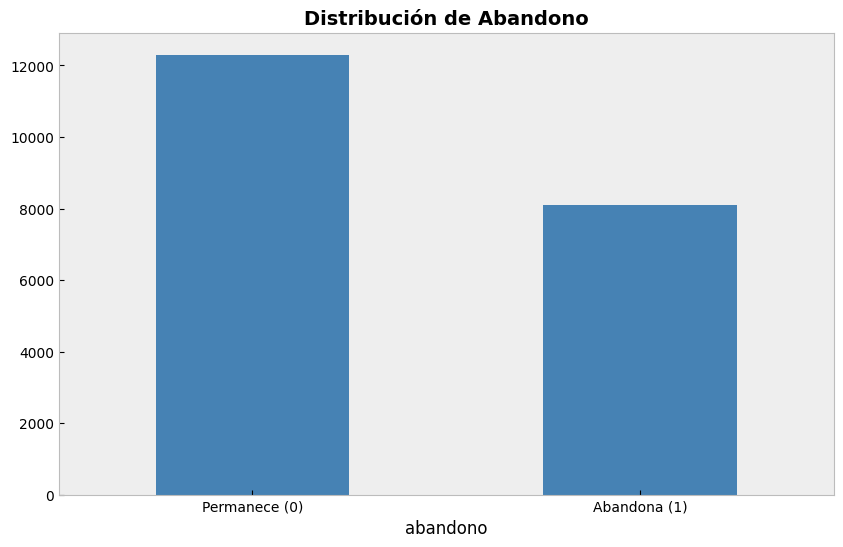

In [37]:
ax = data['abandono'].value_counts().sort_index().plot(
    kind='bar', 
    figsize=(10, 6), 
    color='steelblue',
    width=0.5,
    grid = False
)
plt.title('Distribución de Abandono', fontsize=14, fontweight='bold')
plt.xticks(ticks=[0, 1], labels=['Permanece (0)', 'Abandona (1)'], rotation=0)
plt.show()

## 1.2 Detección de Inconsistencias de Negocio

Antes de analizar estadísticas descriptivas, es necesario verificar la **coherencia semántica** de los datos. Los valores que son técnicamente válidos (sin error de tipo) pero semánticamente absurdos deben ser identificados y tratados:

- `deuda_total < 0`: Una deuda no puede ser negativa en el contexto financiero (podría representar un saldo a favor, pero requiere confirmación del negocio).
- `ingreso_mensual < 0`: Un ingreso negativo carece de sentido económico.
- `edad < 18` o `edad > 100`: Fuera del rango etario plausible para un cliente de servicio digital.
- `antiguedad_meses < 0`: La antigüedad no puede ser negativa.

**Decisión técnica:** Los valores `deuda_total < 0` se tratarán como inconsistencias y serán winsurizados en el pipeline de preprocesamiento (limitados por percentil 5%). Esta decisión es preferible a la eliminación de filas, ya que preserva el volumen de datos de entrenamiento.

In [38]:
# Detectar valores que no tienen sentido de negocio
inconsistentes = data[
    (data['deuda_total'] < 0) |
    (data['ingreso_mensual'] < 0) |
    (data['edad'] < 18) | (data['edad'] > 100) |
    (data['antiguedad_meses'] < 0)
]
inconsistentes[['edad','ingreso_mensual',
                          'deuda_total','antiguedad_meses']].head(10)

,edad,ingreso_mensual,deuda_total,antiguedad_meses
45,54,5.473621e+05,-8694.468176,22
70,61,7.716767e+05,-140806.057898,15
183,51,1.302779e+06,-348532.147302,22
333,23,1.164257e+06,-45067.673765,32
386,52,2.314476e+05,-486854.930914,98
436,59,8.502537e+05,-57991.545384,25
625,60,9.012112e+05,-30196.798683,47
727,20,8.008237e+05,-51381.443872,15
741,52,8.260922e+05,-188756.783598,35
810,36,1.018660e+06,-161457.353388,110


In [39]:
print('Deuda total negativa    :', (data['deuda_total'] < 0).sum())
print('Ingreso mensual negativo:', (data['ingreso_mensual'] < 0).sum())

Deuda total negativa    : 143
Ingreso mensual negativo: 11


## 1.3 Detección y Tratamiento de Valores Nulos

Los valores nulos constituyen un problema frecuente en datos empresariales. Se deben identificar las variables afectadas y seleccionar una estrategia de imputación apropiada según la naturaleza de cada variable.

**Estrategias disponibles:**
- **Imputación por media** (`SimpleImputer(strategy='mean')`): Adecuada para variables numéricas continuas con distribución aproximadamente simétrica. Preserva la media del conjunto de entrenamiento sin introducir sesgos extremos.
- **Imputación por mediana**: Más robusta ante valores atípicos, pero puede distorsionar distribuciones asimétricas.
- **Imputación por moda** (`strategy='most_frequent'`): Apropiada para variables categóricas.

**Decisión técnica adoptada:** Se aplica imputación por media para las variables numéricas (`ingreso_mensual`, `gasto_mensual`, `score_crediticio`) dado que el porcentaje de nulos es bajo (~5%). Esta estrategia minimiza el impacto sobre la distribución original y es consistente con las mejores prácticas de Scikit-learn. La imputación se encapsula dentro del `Pipeline` para garantizar que se aprende únicamente sobre el conjunto de entrenamiento, evitando *data leakage*.

In [40]:
nulos = data.isnull().sum()
nulos_pct = (nulos / len(data) * 100).round(2)

resumen = pd.DataFrame({'Nulos': nulos}).query('Nulos > 0').sort_values('Nulos')

resumen

,Nulos
ingreso_mensual,1021
score_crediticio,1021
gasto_mensual,1025


## 1.4 Análisis de Valores Atípicos (*Outliers*)

Los valores atípicos pueden distorsionar el entrenamiento de modelos sensibles a la escala (como la Regresión Lineal y SVM). Se analiza su presencia en las variables numéricas continuas mediante diagramas de caja (*boxplots*).

**Técnica adoptada — Winsorización por percentil:** En lugar de eliminar filas con outliers (pérdida de datos) o ignorarlos (sesgo en modelos lineales), se aplica **winsorización al percentil 5% y 95%**, recortando los valores extremos al límite más cercano dentro del rango aceptable. Esta técnica:
- Preserva el número total de observaciones.
- Reduce la influencia de valores extremos sobre los coeficientes de regresión.
- Es especialmente importante para `deuda_total` (que presentó valores negativos) e `ingreso_mensual`.

La winsorización se implementa mediante el transformador personalizado `Winsorizer` dentro del `Pipeline`, asegurando que los percentiles se calculen únicamente sobre el conjunto de entrenamiento.

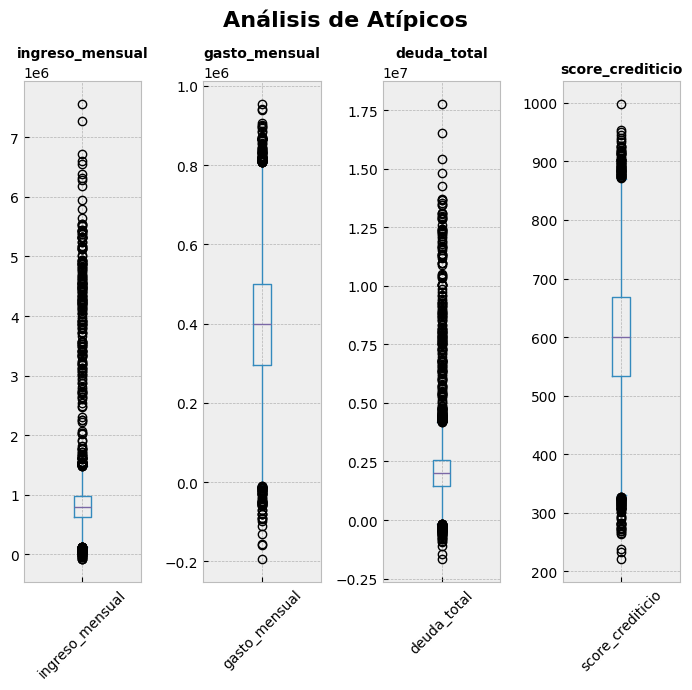

In [41]:
revision_atipicos = [
    'ingreso_mensual', 'gasto_mensual', 'deuda_total',
    'score_crediticio'
]

fig, axes = plt.subplots(1, 4, figsize=(24, 12))
axes = axes.flatten()

for i, col in enumerate(revision_atipicos):
    data[col].plot(kind='box', figsize=(7, 7), ax=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].tick_params(axis='x', labelrotation=45)

plt.suptitle('Análisis de Atípicos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/01_atipicos.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.5 Detección y Tratamiento de Duplicados

Los registros duplicados pueden sesgar el entrenamiento al sobre-representar ciertos patrones, inflando artificialmente las métricas de evaluación si esos registros caen tanto en entrenamiento como en prueba.

**Decisión técnica:** Se eliminan las filas completamente duplicadas (`drop_duplicates()`). Se verifica además si los duplicados son por `id_cliente` para distinguir entre duplicados exactos (error de carga) vs. clientes con múltiples registros (transacciones distintas). En este caso, los 400 duplicados de `id_cliente` comparten todos sus atributos, confirmándose que son duplicados de carga que deben eliminarse.

In [42]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(400)

In [43]:
# Duplicados por id_cliente
dup_id = data.duplicated(subset=['id_cliente']).sum()
print(f'IDs de cliente duplicados: {dup_id}')
data[data.duplicated(subset=['id_cliente'], keep=False)]

IDs de cliente duplicados: 400


,id_cliente,fecha_registro,edad,genero,region,estado_civil,ingreso_mensual,gasto_mensual,deuda_total,score_crediticio,...,ultima_compra_dias,uso_app,tipo_plan,num_productos,tiene_tarjeta_credito,canal_registro,dia_semana_registro,hora_registro,codigo_postal,abandono
177,178,2022-02-16,58,Otro,Centro,Soltero,5.747343e+05,124060.694605,1.567047e+06,706.773275,...,133,Alto,Premium,2,0,Tienda,Sabado,11,8146,1
215,216,2021-05-23,77,Femenino,Centro,Divorciado,6.962513e+05,755824.522948,2.522168e+06,691.380909,...,217,Alto,Estandar,5,1,App,Sabado,6,4541,1
326,327,2019-07-15,43,Femenino,Sur,Soltero,6.110187e+05,238932.156632,8.764364e+05,618.183493,...,303,Medio,Basico,3,0,App,Lunes,11,6291,0
353,354,2020-06-12,53,Otro,Sur,Divorciado,2.275127e+05,602873.962513,2.863745e+06,473.807220,...,180,Bajo,Premium,4,1,Web,Domingo,9,5028,1
415,416,2023-06-18,52,Otro,Sur,Soltero,7.190312e+05,566826.800985,2.735518e+06,586.009635,...,107,Bajo,Premium,5,0,Web,Martes,7,1813,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20395,4925,2021-08-09,47,Femenino,Centro,Divorciado,4.818457e+05,523321.283921,1.750852e+06,715.276140,...,39,Alto,Basico,1,0,Web,Viernes,4,5831,0
20396,1627,2021-10-26,18,Masculino,Sur,Divorciado,1.062000e+06,692112.449676,1.865442e+06,662.855074,...,319,Bajo,Premium,3,0,Web,Domingo,17,2925,0
20397,13007,2022-10-05,76,Femenino,Norte,Soltero,1.595617e+06,568544.699045,1.862204e+06,640.595219,...,325,Medio,Estandar,4,0,App,Viernes,16,1660,0
20398,17724,2020-01-10,23,Otro,Sur,Casado,8.056724e+05,348930.779211,2.032151e+06,466.372014,...,81,Bajo,Premium,2,0,Tienda,Lunes,14,4561,1


## 1.6 Análisis de Correlaciones

La correlación de Pearson mide la **relación lineal** entre variables numéricas. Es útil para:
1. Identificar predictores numéricos con mayor asociación con la variable objetivo.
2. Detectar **multicolinealidad** (correlación alta entre predictores), que puede desestabilizar los coeficientes de regresión lineal.

**Nota metodológica:** Dada la naturaleza binaria de `abandono`, la correlación de Pearson es un indicador aproximado (el coeficiente *point-biserial* sería más preciso). Sin embargo, para una exploración inicial es suficiente para priorizar variables.

In [44]:
# Calcula la matriz de correlaciones
cols_excluir = ['id_cliente', 'codigo_postal', 'hora_registro']
correlaciones = data.drop(columns=cols_excluir, errors='ignore').corr(numeric_only=True)

# Ver correlación con la variable objetivo
corr_abandono = correlaciones['abandono'].drop('abandono').sort_values(ascending=False)
corr_abandono

ultima_compra_dias       0.212881
deuda_total              0.027894
edad                     0.006120
ingreso_mensual          0.002454
tiene_tarjeta_credito   -0.000523
num_productos           -0.002652
antiguedad_meses        -0.005942
gasto_mensual           -0.008417
score_crediticio        -0.028777
frecuencia_compra       -0.044331
Name: abandono, dtype: float64

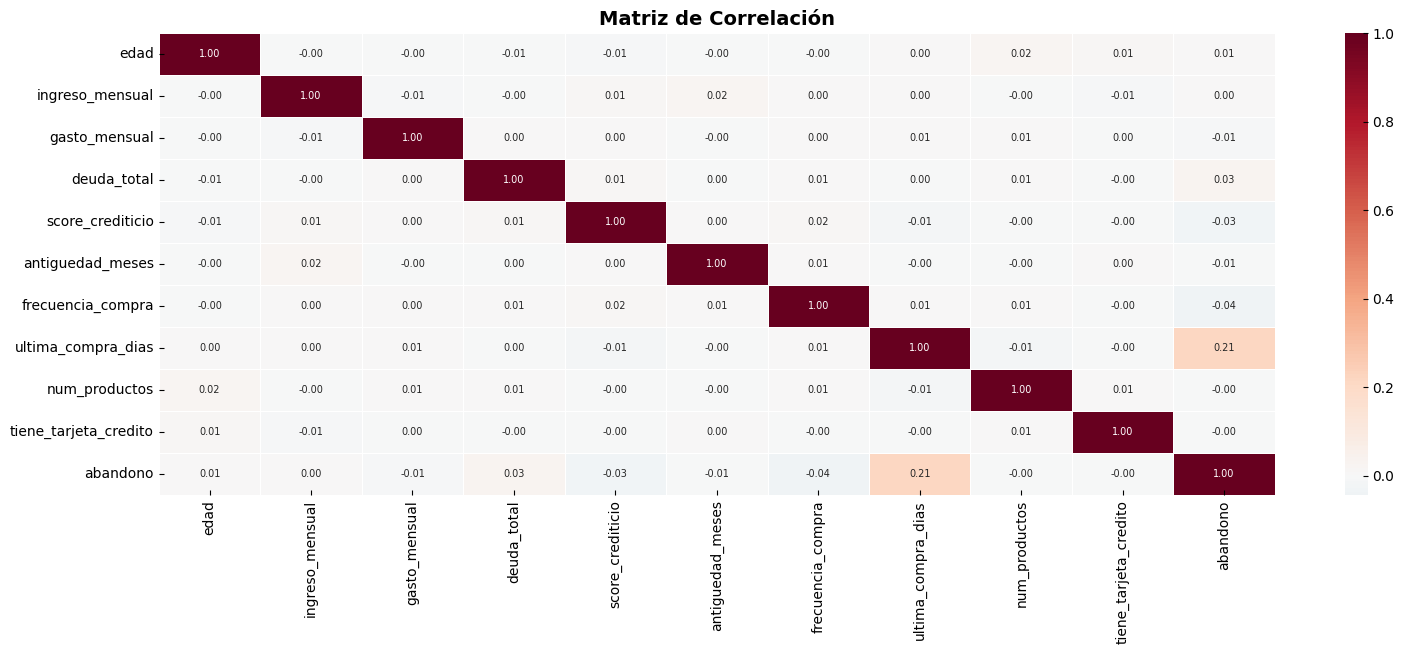

In [45]:
fig, ax = plt.subplots(figsize=(18, 6))

sb.heatmap(correlaciones, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Matriz de Correlación', fontsize=14, fontweight='bold')
ax.grid(False)

plt.savefig('../results/plots/01_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.7 Correlación de Variables Categóricas con el Abandono

Las variables categóricas no son directamente comparables mediante correlación de Pearson. Para incorporarlas al análisis de asociación, se aplica **One-Hot Encoding** (OHE) y se calcula la correlación de cada categoría codificada con `abandono`.

**Justificación del OHE:** Transforma cada categoría en una variable binaria indicadora, permitiendo calcular correlaciones *point-biserial* aproximadas. Esto es consistente con el preprocesamiento que se aplicará en el modelado, donde el `OneHotEncoder` de Scikit-learn con `drop='first'` evita la trampa de la dummy variable.

In [46]:
cats = ['genero', 'region', 'estado_civil', 'uso_app', 'tipo_plan', 'canal_registro']

encoder = OneHotEncoder(sparse_output=False)
cats_encoded = encoder.fit_transform(data[cats].fillna('Desconocido'))
data_ohe = pd.DataFrame(cats_encoded, columns=encoder.get_feature_names_out())

data_corr = pd.concat([data.reset_index(drop=True), data_ohe], axis=1)
corr_cat = data_corr.corr(numeric_only=True)['abandono'][data_ohe.columns]

print('Correlación variables categóricas con abandono:')
display(corr_cat.sort_values(ascending=False))

Correlación variables categóricas con abandono:


uso_app_Bajo               0.188483
tipo_plan_Basico           0.092995
region_Sur                 0.010178
canal_registro_Tienda      0.009399
genero_Otro                0.005803
region_Centro              0.004641
estado_civil_Divorciado    0.004244
canal_registro_App        -0.000134
estado_civil_Soltero      -0.000742
genero_Masculino          -0.001880
estado_civil_Casado       -0.003492
genero_Femenino           -0.003982
canal_registro_Web        -0.009277
region_Norte              -0.014820
tipo_plan_Estandar        -0.042450
tipo_plan_Premium         -0.049823
uso_app_Alto              -0.093460
uso_app_Medio             -0.095918
Name: abandono, dtype: float64

## 1.8 Tasa de Abandono por Variable Categórica

El análisis de la tasa de abandono promedio por categoría permite identificar **segmentos de riesgo** y generar hipótesis causales para el negocio. Se utiliza `groupby` + `mean()` sobre la variable `abandono` para calcular la proporción de clientes que abandonaron dentro de cada grupo.

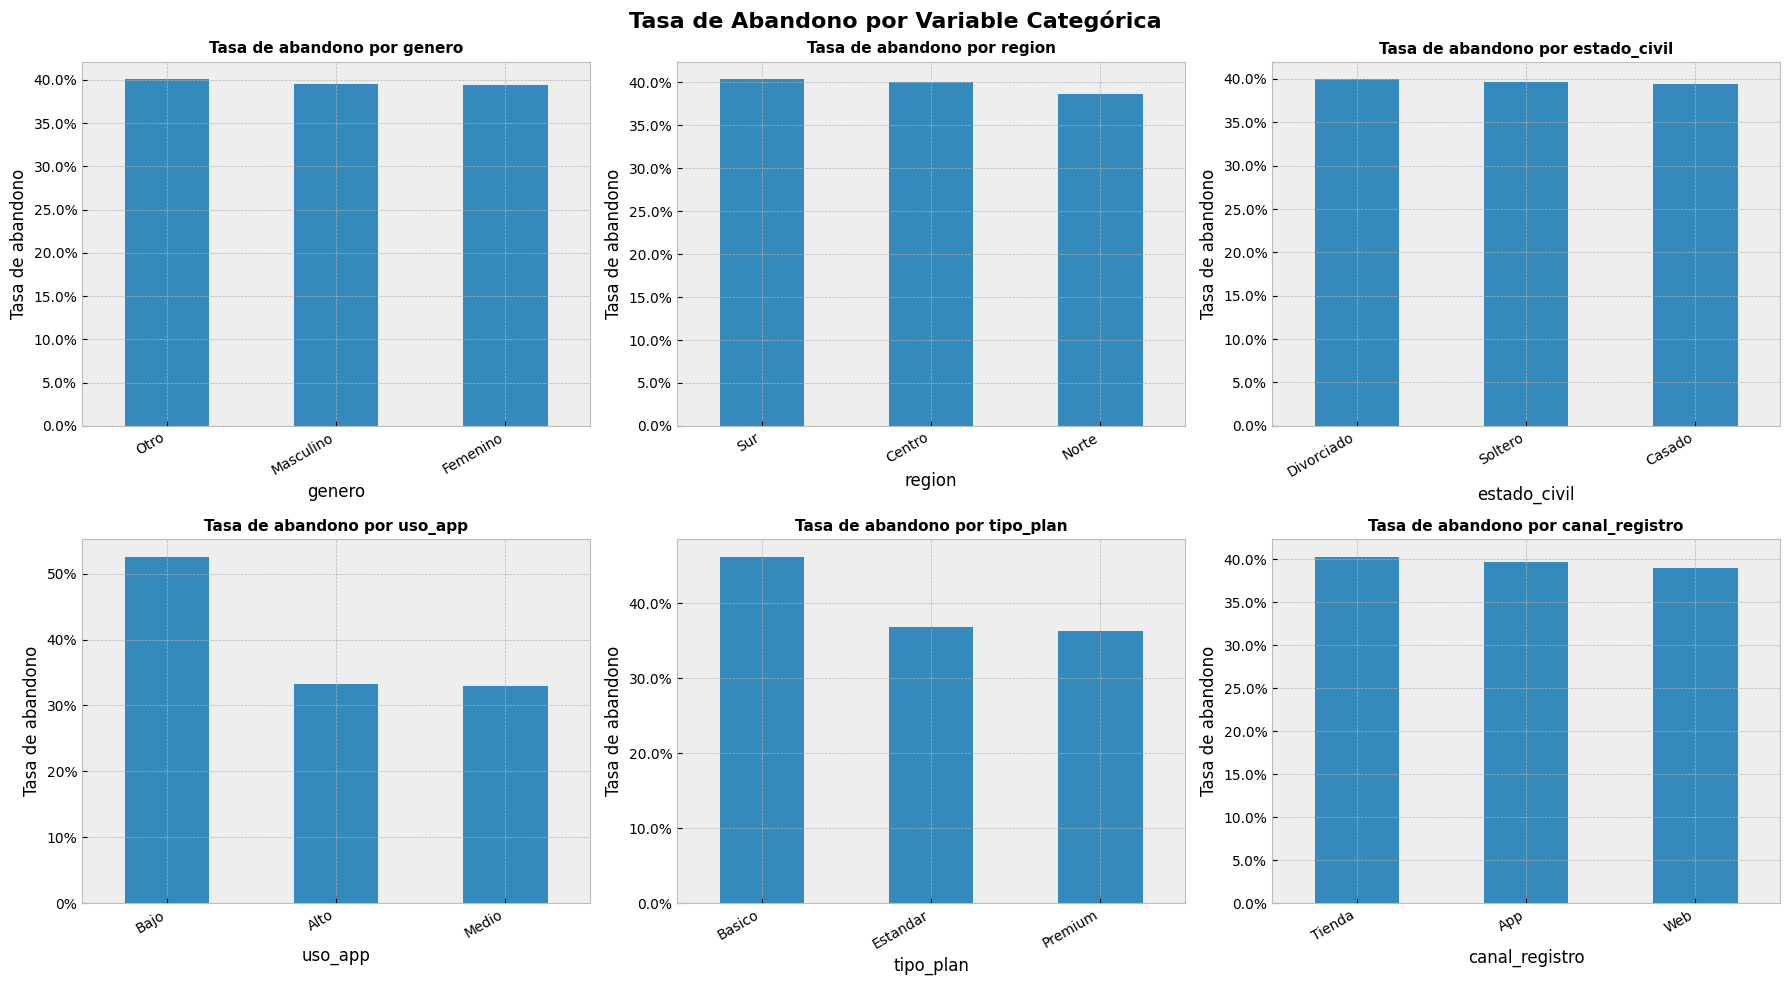

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cats):
    tasa = data.groupby(col)['abandono'].mean().sort_values(ascending=False)
    tasa.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Tasa de abandono por {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Tasa de abandono')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Tasa de Abandono por Variable Categórica', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/01_categoricas_abandono.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.9 Distribución del Score Crediticio (Variable Objetivo de Regresión)

Además del problema de clasificación principal, el dataset contiene la variable continua `score_crediticio`, que representa el perfil financiero del cliente. Su distribución aproximadamente normal la hace un candidato adecuado para modelos de **regresión supervisada**.

**Justificación de `score_crediticio` como target de regresión:**
- Es una variable continua con distribución casi normal (media ≈ 600, DE ≈ 100).
- Tiene relevancia de negocio: predecir el perfil crediticio de nuevos clientes apoya decisiones de riesgo y segmentación.
- Permite demostrar el uso de métricas de regresión (R², MAE, RMSE) con los modelos `LinearRegression` y `DecisionTreeRegressor` requeridos por la rúbrica.

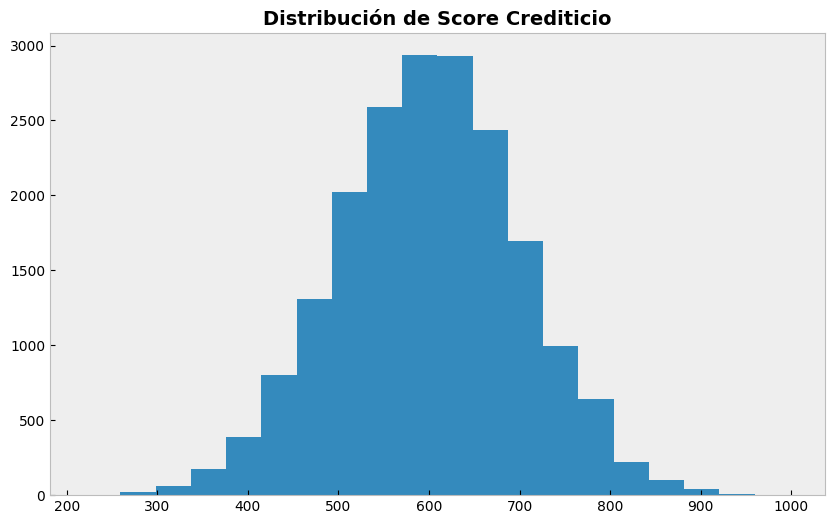

In [48]:
data['score_crediticio'].hist(bins=20, figsize=(10, 6), grid=False)
plt.title('Distribución de Score Crediticio', fontsize=14, fontweight='bold')
plt.show()

In [49]:
data['score_crediticio'].describe().round(2)

count    19379.00
mean       600.44
std        100.41
min        220.52
25%        532.87
50%        600.96
75%        668.25
max        998.29
Name: score_crediticio, dtype: float64

## 2. Conclusiones del EDA e Hipótesis para el Modelado

### Hallazgos principales

| # | Hallazgo | Implicación para el modelado |
|---|---|---|
| 1 | **Desbalance de clases** en `abandono` | Usar `class_weight='balanced'` y priorizar **Recall** sobre Accuracy |
| 2 | **`ultima_compra_dias`** tiene la mayor correlación numérica con `abandono` (r=0.21) | Variable de alta importancia; incluir obligatoriamente |
| 3 | **`uso_app_Bajo`** y **`tipo_plan_Basico`** son los predictores categóricos más fuertes | Clientes con bajo uso digital y plan básico tienen mayor riesgo |
| 4 | **~5% de nulos** en `ingreso_mensual`, `gasto_mensual`, `score_crediticio` | Imputación por media dentro del pipeline |
| 5 | **143 registros con `deuda_total < 0`** y **11 con `ingreso_mensual < 0`** | Winsorización al percentil 5%-95% |
| 6 | **400 filas duplicadas** exactas | Eliminación antes del entrenamiento |
| 7 | `score_crediticio` sigue distribución aproximadamente normal | Adecuado como variable objetivo de regresión |

### Hipótesis de negocio

> **H1:** Los clientes con bajo uso de la aplicación y plan básico tienen una probabilidad significativamente mayor de abandonar. Esto sugiere que intervenciones orientadas a aumentar el engagement digital reducirían el churn.

> **H2:** Los clientes con alta `ultima_compra_dias` (mucho tiempo sin comprar) están en riesgo inminente de abandono. Un sistema de alertas basado en este umbral podría activar campañas de retención proactivas.

### Próximos pasos

El análisis exploratorio sienta las bases para el notebook `02_supervised_modeling.ipynb`, donde se implementarán los modelos de clasificación y regresión con los hallazgos anteriores como guía de diseño del pipeline de preprocesamiento.